<div align="center">
  <img src="images/fimbox.png" alt="fimbox" width="160"/>
  <h2>Getting started with FIMbox</h2>
  <h4>A FIM sandbox for model development and analysis</h4>
</div>

> **Draft** — starting point for the fimbox documentation; text, parameters, and graphics keep refined.

`fimbox` is a modular, open-source **testbed framework for Flood Inundation Mapping (FIM) experimentation**: it standardizes FIM simulation and evaluation with custom datasets and hydrologic parameters in reproducible workflows. It provides a streamlined, cloud-enabled pipeline to generate flood maps based on different modeling frameworks. The overarching goal is to have multimodel capability from terrain based models to hydrodynamic models for modeling. At this time the FIM is based on NOAA OWP **Height Above Nearest Drainage (HAND)** framework, driven by **National Water Model (NWM)** retrospective and forecast streamflow. There is seamless integration of FIM modeling to evaluation with FIMeval (https://github.com/sdmlua/fimeval) where benchmarking is powered by the FIMbench database (https://github.com/sdmlua/fimbench).

`fimbox` is developed at the [Surface Dynamics Modeling Lab (SDML)](https://sdml.ua.edu), The University of Alabama.

**This notebook runs the complete workflow for one example case** — `test_smallB`, whose boundary shapefile ships with the docs at [`test_boundary/test_smallB.shp`](test_boundary). All outputs land in `fimbox_output/test_smallB/` next to this notebook.

**Contents**

1. [Installation & setup](#1.-Installation-&-setup)
2. [Stage AOI input data](#2.-Stage-AOI-input-data)
3. [Bridge DEM processing (optional)](#3.-Bridge-DEM-processing-(optional))
4. [Branch processing — HAND + synthetic rating curves](#4.-Branch-processing-HAND-+-synthetic-rating-curves)
5. [Rating-curve calibration](#5.-Rating-curve-calibration)
6. [Streamflow retrieval](#6.-Streamflow-retrieval)
7. [FIM generation](#7.-FIM-generation)


### **Workflow at a glance**

The pipeline runs in six major steps- stage inputs, (optionally) heal bridges, build HAND and rating curves per branch, calibrate the rating curves, retrieve discharge, and map the flood. Each section below is one self-contained code cell; run them in order.

<div align="center">
  <img src="images/fimbox-flowchart.png" alt="fimbox workflow" width="1000"/>
</div>


---
### **1. Installation & setup**

`fimbox` is published on [PyPI](https://pypi.org/project/fimbox/) and targets Python 3.10–3.12. Install it into a fresh virtual environment:


In [4]:
# %pip install uv
# %uv pip install fimbox

In [6]:
# Verify the install and set up the paths used throughout this notebook
from importlib.metadata import version
from pathlib import Path

import fimbox

BOUNDARY = Path("test_boundary/test_smallB.shp")  # example AOI shipped with the docs
OUT_DIR = Path("fimbox_output")  # data root; the AOI dir is created inside
AOI_DIR = OUT_DIR / "test_smallB"  # <out_dir>/<aoi_id>
WATERSHED = AOI_DIR / "watershed-data"  # where all staged inputs live
IDENTIFIER = "nwmmr"  # filename prefix for staged hydrography
N_WORKERS = 4  # parallel workers for the heavy steps

### **The example AOI**

A quick look at the boundary polygon this notebook will process:


,fid,geometry
0,1.0,"POLYGON ((-78.234 35.33339, -78.16418 35.48094..."


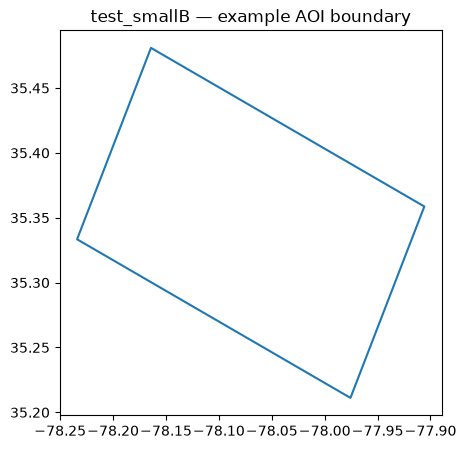

In [9]:
import geopandas as gpd

boundary = gpd.read_file(BOUNDARY)
ax = boundary.plot(
    figsize=(5, 5), facecolor="none", edgecolor="tab:blue", linewidth=1.5
)
ax.set_title("test_smallB — example AOI boundary")
boundary

### **Reference datasets (fetched on demand)**

The crosswalk and calibration steps rely on several lookup tables — IRIS-SWORD slopes, NWM recurrence/high-water flows, USGS rating curves, optimized Manning's n, and channel bathymetry. `fimbox.datasets.fetch_data` pulls each one anonymously from the public SDML S3 bucket on first use, and caches it locally (override the cache location with `$FIMBOX_DATA_DIR`) — **no manual download needed**:


In [8]:
from fimbox.datasets import DATASETS, fetch_data

print(sorted(DATASETS))  # available aliases

# First call downloads + caches; later calls are instant
print(fetch_data("nwm3_high_water_threshold"))

['acceptable_gages', 'bathymetry_ehydro_ohrfc', 'iris_sword_slopes', 'mannings_optz', 'nwm3_high_water_threshold', 'nwm3_recurrence_flows', 'usgs_rating_curves']
/Users/Supath/Library/Caches/fimbox/nwm3_high_water_threshold_cms.parquet


---
### **2. Stage AOI input data**

`fimbox.getAllInputData` stages every input the downstream pipeline needs into `<out_dir>/<aoi_id>/watershed-data/`: the 3DEP DEM (reprojected, clipped, hole-filled), NWM or NHDPlus HR flowlines/catchments/lakes, headwater points, FEMA NFHL, NLD levees, OSM roads and bridges, and USGS gages. The AOI can be a **boundary polygon file** or an **8-digit HUC code**, and you can bring your own flowlines/catchments/DEM from any source - they are normalized to the pipeline schema automatically.

<div align="center">
  <img src="../workflows/svg/download_data.svg" alt="download_data workflow" width = "1000"/>
</div>

In [ ]:
pp = fimbox.getAllInputData(
    boundary=BOUNDARY,
    out_dir=OUT_DIR,
    buffer_m=5000,  # metres to buffer the boundary for data downloads
    headwater_buffer_cells=8,  # DEM cells to shrink the buffer for the headwater clip
    get_flowlines=True,  # False -> bring your own flowlines
    get_catchments=True,  # False -> bring your own catchments
    resolution="medium",  # "medium" -> NWM; "high" -> NHDPlus HR (lakes always NWM)
    identifier=IDENTIFIER,  # filename prefix for all staged hydrography
    # huc8="08060202",         # 8-digit HUC ID — alternative to boundary=...
    # dem_resolution=10,       # 3DEP DEM resolution in metres (1/3/10/30/60)
    # epsg=5070,               # output CRS (NAD83 CONUS Albers)
    # --- bring-your-own inputs (any source, any column names) ---
    # flowlines="my_flowlines.gpkg",
    # catchments="my_catchments.gpkg",
    # stream_fields={"ID": "nhdplusid", "order_": "streamorde", "levpa_id": "levelpathi"},
    # catchment_fields={"ID": "nhdplusid"},
    # dem="my_dem.tif",        # reprojected/clipped/hole-filled like a downloaded DEM
)
pp.run()  # full pipeline; or pp.run_dem() / pp.run_nhd() / pp.run_nld() / pp.run_osm()

Everything is now staged under `fimbox_output/test_smallB/watershed-data/` and organized into the following groups:

- Base spatial inputs
    - `dem.tif`
    - `wbd_buffered.gpkg`

- Hydrography
    - `nwmmr_subset_streams.gpkg`
    - `nwmmr_catchments_proj_subset.gpkg`
    - `nwmmr_lakes_proj_subset.gpkg`
    - headwater points

- Infrastructure and barriers
    - `3d_nld_subset_levees_burned.gpkg`
    - `osm_roads_subset.gpkg`
    - `osm_bridges_subset.gpkg`

- Observations
    - `usgs_gages.gpkg`

All downstream steps read from this staging directory using the shared `IDENTIFIER` prefix (`nwmmr`).


In [ ]:
# Figure: staged DEM + NWM stream network
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(7, 7))
with rasterio.open(WATERSHED / "dem.tif") as src:
    show(src, ax=ax, cmap="terrain")
streams = gpd.read_file(WATERSHED / f"{IDENTIFIER}_subset_streams.gpkg")
streams.plot(ax=ax, color="royalblue", linewidth=0.8)
boundary.to_crs(streams.crs).plot(
    ax=ax, facecolor="none", edgecolor="crimson", linewidth=1.2
)
ax.set_title("Staged inputs — DEM, NWM streams, AOI boundary")
plt.show()

---
### **3. Bridge DEM processing *(optional)***

Bridge decks captured in the DEM block flow paths and bias HAND. This step streams USGS 3DEP LiDAR around each OSM bridge, builds a per-bridge elevation raster, and mosaics the `lidar_elev - dem_elev` difference into `bridge_elev_diff.tif`; branch processing later uses that raster to heal bridges in the HAND grid. **Skip this section if your AOI has no bridges** — the rest of the pipeline runs without it.

<div align="center">
  <img src="../workflows/svg/process_bridgedem.svg" alt="process_bridgedem workflow" width = "1000" />
</div>


In [ ]:
BRIDGES = WATERSHED / "osm_bridges_subset.gpkg"

# Step 1 — stream USGS LiDAR and write one elevation .tif per bridge.
# Safe to re-run: bridges that already have a raster are skipped
# (check progress anytime with .status() instead of .run()).
tif_dir = fimbox.generateBridgeRaster(
    bridge_gpkg=BRIDGES,
    out_dir=WATERSHED,
    resolution=10.0,  # m, output raster resolution
    buffer_m=10.0,  # m, buffer around each bridge footprint
    n_workers=N_WORKERS,
    # id_col="my_id",  # only needed if the gpkg has no "osmid" column
).run()

# Step 2 — mosaic the per-bridge (lidar - dem) differences into one raster.
diff_path = fimbox.BridgeDEMDiff(
    dem_path=WATERSHED / "dem.tif",
    lidar_tif_dir=tif_dir,
    bridge_gpkg=BRIDGES,
    out_dir=WATERSHED,
    out_name="bridge_elev_diff.tif",
    n_workers=N_WORKERS,
).run()

print(f"Bridge difference raster -> {diff_path}")

---
### **4. Branch processing- HAND + synthetic rating curves**

The core HAND step, following the NOAA OWP inundation-mapping logic. `BranchDerivation` derives level paths from the staged stream network and splits the AOI into **branches**. `calculate_allbranches` then runs **branch zero** (whole-AOI DEM conditioning: AGREE stream burning, levee burning, pit-filling, D8 flow directions) followed by every non-zero branch in parallel through the full 22-step HAND workflow — relative elevation model (HAND), catchments, synthetic rating curves (SRC), the NWM crosswalk, and the per-branch `hydroTable_<branch>.csv` that FIM generation consumes.

Every parameter is spelled out below so this cell doubles as the parameter reference — the commented values are the defaults, and each one is an experimentation knob (e.g. `mannings_n`, `max_split_distance_m` for stream segmentation density, `src_slope_source` for the slope feeding Manning's equation).

<div align="center">
  <img src="../workflows/svg/calculate_branch.svg" alt="calculate_branch workflow" width = "1000"/>
</div>


In [ ]:
from fimbox import AOIProcessingConfig, BranchDerivation, calculate_allbranches

# --- derive level paths, branch polygons, and branch_ids.lst ---
BranchDerivation(
    out_dir=WATERSHED,
    branch_id_attribute="levpa_id",
    reach_id_attribute="ID",
    branch_buffer_distance_meters=7000.0,
).run()

# --- optional inputs: passed only when staged by the earlier sections ---
bridge_diff = WATERSHED / "bridge_elev_diff.tif"  # section 3
levees = WATERSHED / "3d_nld_subset_levees_burned.gpkg"  # section 2
headwaters = WATERSHED / f"{IDENTIFIER}_headwater_points_subset.gpkg"
if not headwaters.exists():
    headwaters = WATERSHED / f"{IDENTIFIER}_headwaters.gpkg"
levelpaths_ext = WATERSHED / f"{IDENTIFIER}_subset_streams_levelPaths_extended.gpkg"

cfg = AOIProcessingConfig(
    aoi_dir=WATERSHED,
    branch_list_path=WATERSHED / "branch_ids.lst",
    # Branch-zero inputs (whole-AOI DEM conditioning)
    dem_path=WATERSHED / "dem.tif",
    streams_gpkg=WATERSHED / f"{IDENTIFIER}_subset_streams.gpkg",
    boundary_gpkg=WATERSHED / "wbd_buffered.gpkg",
    bridge_elev_diff_path=bridge_diff if bridge_diff.exists() else None,
    levee_gpkg_path=levees if levees.exists() else None,
    headwaters_gpkg=headwaters if headwaters.exists() else None,
    levelpaths_extended_gpkg=levelpaths_ext if levelpaths_ext.exists() else None,
    # AGREE DEM conditioning
    agree_buffer_m=15.0,
    agree_smooth_drop=10.0,
    agree_sharp_drop=1000.0,
    # HAND geometry
    cost_distance_tolerance=50.0,  # m, lateral cost distance
    lateral_elevation_threshold=10,  # m, lateral thalweg drop cap
    max_split_distance_m=1500.0,  # m, split-reach max length (shorter -> denser catchments)
    slope_min=0.0001,  # rise/run floor
    lakes_buffer_dist_m=100.0,  # m, lake-boundary buffer
    # SRC / crosswalk
    mannings_n=0.06,  # channel roughness
    stage_min_m=0.0,  # SRC stage ladder start
    stage_interval_m=0.3048,  # SRC stage step (1 ft)
    stage_max_m=25.2984,  # SRC stage ladder end (~83 ft)
    min_catchment_area=0.25,  # km^2, short-reach replace threshold
    min_stream_length=0.5,  # km, short-reach replace threshold
    crosswalk_max_distance_m=100.0,  # m, midpoint-to-NWM-flowline cap
    # SRC slope source: "iris_sword" (default) | "dem" | "hfab"
    src_slope_source="iris_sword",
    iris_slope_csv=None,  # None -> packaged IRIS-SWORD table
    hfab_slope_column=None,  # hydrofabric slope column if not Slope/So
    # execution
    n_workers=N_WORKERS,
    keep_failed_branches=True,  # keep failed branch dirs for inspection
    delete_deny_list=True,  # remove per-branch intermediates when done
)

result = calculate_allbranches(
    cfg,
    run_branch_zero=True,
    delete_deny_list=True,  # deny lists default to the ones shipped in fimbox/config/
    branch_ids_csv=WATERSHED / "branch_ids.csv",
)

ok = sum(1 for r in result.branch_results if r.status == "ok")
print(f"branches ok: {ok}/{len(result.branch_results)}")

Each branch now has its own directory under `watershed-data/branches/<branch_id>/`:

- `rem_zeroed_masked_<b>.tif` — the **HAND raster**
- `gw_catchments_reaches_filtered_addedAttributes_crosswalked_<b>.gpkg` — crosswalked catchments
- `hydroTable_<b>.csv` — the **stage → discharge lookup** used by FIM generation
- `src_full_crosswalked_<b>.csv` / `src_<b>.json` — the synthetic rating curves

Branch `0` covers the whole AOI; its D8 flow directions are the shared input for every other branch. `branch_ids.csv` summarises the run status per branch.


In [ ]:
# Figure: HAND raster for one branch
branch = "0"  # pick any id from branch_ids.csv
hand_path = WATERSHED / "branches" / branch / f"rem_zeroed_masked_{branch}.tif"

fig, ax = plt.subplots(figsize=(7, 7))
with rasterio.open(hand_path) as src:
    show(src, ax=ax, cmap="Blues_r", vmax=15)
ax.set_title(f"Height Above Nearest Drainage (HAND) — branch {branch}")
plt.show()

---
## 5. Rating-curve calibration

One `run_calibration()` call drives the whole calibration pipeline over the per-branch rating curves and hydroTables: reset → pre-aggregation → thalweg-notch adjustment → longitudinal smoothing → bathymetric adjustment (eHydro) → bankfull identification → channel/overbank subdivision (variable Manning's n) → non-monotonic fix → USGS rating-curve calibration → spatial/manual calibration → post-aggregation → log scan. Steps whose input file is absent **self-skip**, and every toggle can be turned off independently.

The lookup tables come straight from `fetch_data` (section 1) — nothing to stage by hand.

<div align="center">
  <img src="../workflows/svg/calibrate_ratingcurve.svg" alt="calibrate_ratingcurve workflow"/>
</div>


In [ ]:
from fimbox import CalibrationConfig, run_calibration

cal_cfg = CalibrationConfig(
    # reset — revert hydroTables to the uncalibrated baseline first.
    # Set True when re-calibrating an AOI that was already calibrated.
    calibration_rerun=False,
    # aggregate_pre — assemble usgs/ras2fim elev tables before adjustments
    aggregate_pre=True,
    # thalweg — remove thalweg-notch artifact rows, refill the stage ladder
    thalweg_notches_adjustment=True,
    # longitudinal — smooth hydraulic geometry along reach chains
    longitudinal_filter=True,
    # bathymetry — add missing in-channel area below the DEM (eHydro surveys)
    bathymetry_adjust=True,
    bathy_file_ehydro=fetch_data("bathymetry_ehydro_ohrfc"),
    # bankfull — identify the bankfull stage in every branch SRC
    src_bankfull_toggle=True,
    bankfull_flows_file=fetch_data("nwm3_high_water_threshold"),
    include_branch_zero=True,
    # subdiv — channel/overbank subdivision (needs vmann + bankfull on)
    src_subdiv_toggle=True,
    vmann_input_file=fetch_data("mannings_optz"),
    default_channel_n=0.06,  # used when a feature_id is missing from the vmann table
    default_overbank_n=0.12,
    # nonmonotonic — force monotonic in-channel rating curves
    nonmonotonic_src_adjustment=True,
    nonmonotonic_stream_order_min=4,
    # usgs — calibrate SRCs against USGS rating curves at NWM recurrence flows
    src_adjust_usgs=True,
    usgs_rating_curve_csv=fetch_data("usgs_rating_curves"),
    usgs_acceptable_gages=fetch_data("acceptable_gages"),
    nwm_recur_file=fetch_data("nwm3_recurrence_flows"),
    # spatial — calibrate SRCs against benchmark inundation points
    src_adjust_spatial=True,
    calib_points_file=None,  # None -> step self-skips
    # manual — apply a per-feature_id coefficient table
    manual_calb_toggle=True,
    man_calb_file=None,  # None -> step self-skips
    # aggregate_post — publish htable + bridge + road tables to the AOI root
    aggregate_post=True,
    # log scan — collect error/warning lines into per-AOI summary files
    scan_logs=True,
    # execution
    job_branch_limit=N_WORKERS,
    skip_unimplemented=True,  # warn instead of raising on stub steps
)

run_calibration(AOI_DIR, cal_cfg)

Each branch `hydroTable_<b>.csv` and `src_full_crosswalked_<b>.csv` has been rewritten in place with the calibrated discharges plus the subdivision columns (`subdiv_discharge_cms`, `channel_n`, `overbank_n`, ...). Aggregated tables are published to the AOI root, and `logs/` gains per-AOI error/warning summaries.


In [ ]:
# Figure: synthetic rating curve before/after subdivision for one reach
import pandas as pd

branch = "0"
ht = pd.read_csv(
    WATERSHED / "branches" / branch / f"hydroTable_{branch}.csv", dtype={"HydroID": str}
)
hydro_id = ht["HydroID"].iloc[0]  # pick any reach
curve = ht[ht["HydroID"] == hydro_id]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(curve["discharge_cms"], curve["stage"], label="SRC (calibrated)")
if "subdiv_discharge_cms" in curve.columns:
    ax.plot(
        curve["subdiv_discharge_cms"], curve["stage"], "--", label="SRC (subdivided)"
    )
ax.set_xlabel("discharge (cms)")
ax.set_ylabel("stage (m)")
ax.set_title(f"Synthetic rating curve — branch {branch}, HydroID {hydro_id}")
ax.legend()
plt.show()

---
## 6. Streamflow retrieval

`fimbox.streamflow` retrieves the discharge that drives FIM generation and supports its evaluation: **NWM v3.0 retrospective**, **NWM operational forecasts** (short/medium/long range), GEOGLOWS v2, and **USGS gage observations**. Retrieved series are archived under `<aoi>/streamflow/` and exported as FIM-ready CSVs (`feature_id, discharge_cms`) into `<aoi>/discharge-inputs/` — exactly what the FIM generation step consumes. The reach `feature_id`s come from the AOI's `feature_id.csv`, built automatically from the branch hydroTables.

<div align="center">
  <img src="../workflows/svg/streamflow.svg" alt="streamflow workflow"/>
</div>


In [ ]:
from fimbox import getNWMretrospective

# Example case: one retrospective event instant -> one FIM-ready CSV
EVENT = "2020-05-20 12:00:00"
getNWMretrospective(AOI_DIR, date=EVENT)

# --- other retrieval modes ---
# getNWMretrospective(AOI_DIR, start="2020-05-19", end="2020-05-22")                    # one CSV per hour
# getNWMretrospective(AOI_DIR, start="2020-05-19", end="2020-05-22", sortby="maximum")  # one aggregated CSV
# getNWMretrospective(AOI_DIR, feature_ids=[123456], date=EVENT)   # explicit reaches
# getNWMforecast(AOI_DIR, "shortrange")                            # latest operational cycle
# getNWMforecast(AOI_DIR, "mediumrange", sort_by="maximum")
# getNWMforecast(AOI_DIR, "shortrange", forecast_date="2024-06-01", hour=12)

### Evaluate NWM against USGS observations *(optional)*

`get_usgs_fid_pairs` lists which USGS gage sits on which NWM reach inside the AOI; pick a pair to overlay the hydrographs and compute KGE / NSE / PBias skill scores:


In [ ]:
from fimbox import get_usgs_fid_pairs

pairs = get_usgs_fid_pairs(AOI_DIR)  # which USGS gage sits on which feature_id
print(pairs)

# START, END = "2020-05-01", "2020-06-01"
# USGS_SITE, FEATURE_ID = "07288500", 123456   # <- take one pair from above
# USGSData(AOI_DIR).fetch([USGS_SITE], START, END)                   # archive observations
# plot_comparison(AOI_DIR, FEATURE_ID, USGS_SITE, START, END)        # NWM vs USGS overlay
# calculate_statistics(AOI_DIR, FEATURE_ID, USGS_SITE, START, END)   # KGE / NSE / PBias

---
## 7. FIM generation

The final step: `generateFIM` reads every discharge CSV in `<aoi>/discharge-inputs/`, interpolates each reach's stage from the calibrated hydroTables, inundates every branch HAND raster in parallel, and mosaics the branches into one AOI-wide **flood extent** (and optionally **depth**) raster per CSV in `<aoi>/fim-outputs/`.

<div align="center">
  <img src="../workflows/svg/fimgeneration.svg" alt="fimgeneration workflow"/>
</div>


In [ ]:
from fimbox import generateFIM

# One flood map (extent + depth) per discharge CSV staged in section 6
fim_results = generateFIM(
    AOI_DIR, n_workers=N_WORKERS, depth=True
).from_discharge_inputs()

for r in fim_results:
    print(f"extent -> {r.extent_path}")
    print(f"depth  -> {r.depth_path}")

# --- selection variants ---
# generateFIM(AOI_DIR).from_discharge_inputs(csv="discharge-inputs/my_event.csv")  # one CSV
# generateFIM(AOI_DIR).from_discharge_inputs(date="2020-05-20 12:00:00")           # by date stamp
# generateFIM(AOI_DIR).from_discharge_inputs(start="2020-05-19", end="2020-05-22") # by range

In [ ]:
# Figure: the generated flood extent over the DEM
import numpy as np

extent_path = fim_results[0].extent_path

fig, ax = plt.subplots(figsize=(8, 8))
with rasterio.open(WATERSHED / "dem.tif") as dem:
    show(dem, ax=ax, cmap="gray")
with rasterio.open(extent_path) as src:
    fim = src.read(1).astype(float)
    fim[fim <= 0] = np.nan
    show(fim, transform=src.transform, ax=ax, cmap="Blues", alpha=0.7)
ax.set_title(f"Flood inundation map — {Path(extent_path).stem}")
plt.show()

---
## Wrap-up

That is the complete `fimbox` workflow for one case:

**staged inputs → (bridge healing) → HAND + rating curves → calibration → discharge → flood maps**

| Output | Where |
|---|---|
| Staged AOI inputs | `fimbox_output/test_smallB/watershed-data/` |
| HAND rasters + hydroTables | `watershed-data/branches/<branch_id>/` |
| Streamflow archives + FIM-ready CSVs | `test_smallB/streamflow/`, `test_smallB/discharge-inputs/` |
| Flood extent / depth rasters | `test_smallB/fim-outputs/` |

`fimbox` is a testbed — to experiment, change a knob upstream and re-run sections 4–7: a different DEM or stream network (bring-your-own inputs in section 2), `mannings_n`, `max_split_distance_m` (stream segmentation density), `src_slope_source`, the calibration toggles, or the forecast product driving the map.

**Further reading**: every module ships a README with its full parameter surface and workflow diagram — see the [module documentation table](../README.md#module-documentation) — and the [`tests/`](../tests) folder doubles as a runnable usage reference for every stage.

*Questions / issues: [github.com/sdmlua/fimbox](https://github.com/sdmlua/fimbox) — Sagy Cohen (sagy.cohen@ua.edu), Supath Dhital (sdhital@ua.edu), SDML, The University of Alabama.*
